    213 aligned faces
       ↓
    ArcFace preprocessing
       ↓
    ArcFace model
       ↓
    512-dimensional embedding
       ↓
    Normalize embedding
       ↓
    Save embedding database

In [3]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
ALIGNED_DIR = Path("./Data/Classmates_Aligned")

EMBEDDINGS_DIR = Path("./Data/Embeddings")
EMBEDDINGS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Aligned dataset:", ALIGNED_DIR.resolve())
print("Embeddings directory:", EMBEDDINGS_DIR.resolve())

Aligned dataset: D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\Data\Classmates_Aligned
Embeddings directory: D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\Data\Embeddings


In [5]:
# Verify the aligned dataset

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

aligned_paths = [
    p
    for p in ALIGNED_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Total aligned images:", len(aligned_paths))

Total aligned images: 213


In [6]:
# inspecting one aligned image
test_path = aligned_paths[0]

image = cv2.imread(str(test_path))

print("Path:", test_path)
print("Shape:", image.shape)
print("dtype:", image.dtype)
print("Min:", image.min())
print("Max:", image.max())

Path: Data\Classmates_Aligned\Abhishek_Halagi\AH1.jpeg
Shape: (112, 112, 3)
dtype: uint8
Min: 0
Max: 255


## Load ArcFace Recognition Model

Good. We can proceed. One important engineering point before the code: since you are using YuNet for detection/alignment, we should not use FaceAnalysis for the embedding step, because FaceAnalysis bundles its own detector and alignment pipeline. Instead, we'll load the recognition model directly and feed it your already aligned 112×112 faces. InsightFace supports loading recognition models directly through insightface.model_zoo.get_model().

For this project, we'll use the buffalo_l recognition model initially. Its recognition backbone is ResNet-50 and the standard InsightFace workflow exposes normalized face embeddings; the current documentation also reports 512-dimensional embeddings for the default recognition workflow.

In [7]:
# install 
%pip install -U insightface onnxruntime

Note: you may need to restart the kernel to use updated packages.


In [8]:
import cv2
import numpy as np
import pandas as pd

from pathlib import Path

import insightface

In [9]:
print("InsightFace version:", insightface.__version__)

InsightFace version: 1.0.1


In [10]:
# Defining you paths
ALIGNED_DIR = Path("./Data/Classmates_Aligned")

EMBEDDINGS_DIR = Path("./Data/Embeddings")

EMBEDDINGS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Aligned dataset:", ALIGNED_DIR.resolve())
print("Embeddings directory:", EMBEDDINGS_DIR.resolve())

Aligned dataset: D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\Data\Classmates_Aligned
Embeddings directory: D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\Data\Embeddings


In [11]:
#Verify aligned images
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

aligned_paths = sorted([
    p
    for p in ALIGNED_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
])

print("Total aligned images:", len(aligned_paths))

Total aligned images: 213


In [12]:
# Load the ArcFace recognition model
recognition_model = insightface.model_zoo.get_model(
    "buffalo_l",
    providers=["CPUExecutionProvider"]
)

recognition_model.prepare(ctx_id=-1)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


In [13]:
# Better approach: use the actual recognition ONNX model

from pathlib import Path

insightface_root = Path.home() / ".insightface" / "models"

print(insightface_root)

C:\Users\Nikhil\.insightface\models


In [14]:
for p in insightface_root.rglob("*.onnx"):
    print(p)

C:\Users\Nikhil\.insightface\models\buffalo_l\1k3d68.onnx
C:\Users\Nikhil\.insightface\models\buffalo_l\2d106det.onnx
C:\Users\Nikhil\.insightface\models\buffalo_l\det_10g.onnx
C:\Users\Nikhil\.insightface\models\buffalo_l\genderage.onnx
C:\Users\Nikhil\.insightface\models\buffalo_l\w600k_r50.onnx


In [15]:
# Test one embedding first
test_path = aligned_paths[0]

print(test_path)

Data\Classmates_Aligned\Abhishek_Halagi\AH1.jpeg


In [16]:
image = cv2.imread(str(test_path))

if image is None:
    raise ValueError("Could not read image.")

print("Shape:", image.shape)
print("dtype:", image.dtype)

Shape: (112, 112, 3)
dtype: uint8


In [17]:
print(type(recognition_model))

<class 'insightface.model_zoo.arcface_onnx.ArcFaceONNX'>


In [18]:
print(insightface.__version__)

1.0.1


In [19]:
embedding = recognition_model.get_feat(image)

In [20]:
print("Embedding type:", type(embedding))
print("Embedding shape:", embedding.shape)
print("Embedding dtype:", embedding.dtype)

Embedding type: <class 'numpy.ndarray'>
Embedding shape: (1, 512)
Embedding dtype: float32


In [21]:
#Convert it to a 1-D vector
embedding = embedding.flatten()

print("Final embedding shape:", embedding.shape)

Final embedding shape: (512,)


In [22]:
# check Normalization
norm = np.linalg.norm(embedding)

print("L2 norm:", norm)

L2 norm: 21.982542


In [23]:
embedding_normalized = embedding / (
    np.linalg.norm(embedding) + 1e-12
)

print(
    "Normalized L2 norm:",
    np.linalg.norm(embedding_normalized)
)

Normalized L2 norm: 1.0


    Original image
          ↓
    YuNet
          ↓
    5 landmarks
          ↓
    Your alignment code
          ↓
    112 × 112 aligned face
          ↓
    ArcFaceONNX.get_feat()
          ↓
    512-D embedding

## Validate ArcFace with Similarity

Same person → high similarity ->
Different person → lower similarity

In [24]:
# cosine similarity function
# Because both vectors are L2-normalized, the dot product is equivalent to cosine similarity.
def cosine_similarity(embedding1, embedding2):
    embedding1 = np.asarray(embedding1, dtype=np.float32)
    embedding2 = np.asarray(embedding2, dtype=np.float32)

    embedding1 = embedding1 / (np.linalg.norm(embedding1) + 1e-12)
    embedding2 = embedding2 / (np.linalg.norm(embedding2) + 1e-12)

    return float(np.dot(embedding1, embedding2))

In [25]:
#Create a function to generate an embedding
def generate_embedding(image_path):
    
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    # ArcFace expects the aligned face
    embedding = recognition_model.get_feat(image)

    embedding = embedding.flatten().astype(np.float32)

    # L2 normalization
    embedding = embedding / (
        np.linalg.norm(embedding) + 1e-12
    )

    return embedding

In [26]:
# Select two images from the SAME person
from collections import defaultdict

person_images = defaultdict(list)

for path in aligned_paths:
    person = path.parent.name
    person_images[person].append(path)

for person, paths in person_images.items():
    print(person, len(paths))

Abhishek_Halagi 17
Darshan_Khadakhadi 15
Darshan_Netegal 12
Dhurvankur_ 22
Harshad_Bhairatkar 16
Mahesh_Oulkar 10
Nikhil_Kanbarkar 25
Pranav_Kavale 6
Rohan_Kamble 6
Rohit_Patil 24
Sahil_Kurbet 5
Sahil_Patil 30
Suraj_Mallur 14
Vishwanath_Muchandi 11


In [27]:
# pick the person with several images for ex. : nikhil_kanbarkar
person_a = "Nikhil_Kanbarkar"

images_a = person_images[person_a]

print("Person:", person_a)
print("Number of images:", len(images_a))

Person: Nikhil_Kanbarkar
Number of images: 25


In [28]:
image_a1 = images_a[0]
image_a2 = images_a[1]

print(image_a1)
print(image_a2)

Data\Classmates_Aligned\Nikhil_Kanbarkar\NK10.jpeg
Data\Classmates_Aligned\Nikhil_Kanbarkar\NK11.jpeg


In [29]:
# Generate the embeddings for the same person 
embedding_a1 = generate_embedding(image_a1)
embedding_a2 = generate_embedding(image_a2)

print("Embedding 1:", embedding_a1.shape)
print("Embedding 2:", embedding_a2.shape)

Embedding 1: (512,)
Embedding 2: (512,)


In [30]:
# Calculate same person similarity
same_person_similarity = cosine_similarity(
    embedding_a1,
    embedding_a2
)

print(
    "Same-person cosine similarity:",
    same_person_similarity
)

Same-person cosine similarity: 0.7316640019416809


You will likely get a relatively high value, but do not assume a fixed threshold such as 0.6 or 0.7 yet.

For your project, we'll determine an appropriate threshold empirically.

In [31]:
# Pick a different person
person_b = next(
    person
    for person in person_images
    if person != person_a
)

images_b = person_images[person_b]

image_b1 = images_b[0]

print("Different person:", person_b)
print("Image:", image_b1)

Different person: Abhishek_Halagi
Image: Data\Classmates_Aligned\Abhishek_Halagi\AH1.jpeg


In [32]:
# Generate embeddings 
embedding_b1 = generate_embedding(image_b1)

In [33]:
# Different persons similarity
different_person_similarity = cosine_similarity(
    embedding_a1,
    embedding_b1
)

print(
    "Different-person cosine similarity:",
    different_person_similarity
)

Different-person cosine similarity: 0.17957669496536255


Same person       → higher similarity <br>
Different person  → lower similarity

In [34]:
# Test several pairs
# One pair isn't enough. We'll calculate multiple comparisons.
# Same persons comparison

same_results = []

for person, paths in person_images.items():

    if len(paths) < 2:
        continue

    emb1 = generate_embedding(paths[0])
    emb2 = generate_embedding(paths[1])

    similarity = cosine_similarity(
        emb1,
        emb2
    )

    same_results.append({
        "person": person,
        "similarity": similarity
    })

same_df = pd.DataFrame(same_results)

same_df

,person,similarity
0,Abhishek_Halagi,0.578751
1,Darshan_Khadakhadi,0.584147
2,Darshan_Netegal,0.765677
3,Dhurvankur_,0.824012
4,Harshad_Bhairatkar,0.619298
5,Mahesh_Oulkar,0.574869
6,Nikhil_Kanbarkar,0.731664
7,Pranav_Kavale,0.699112
8,Rohan_Kamble,0.651832
9,Rohit_Patil,0.378821


In [35]:
print("Same-person comparisons:", len(same_df))
print()
print(same_df["similarity"].describe())

Same-person comparisons: 14

count    14.000000
mean      0.611914
std       0.129104
min       0.378821
25%       0.575840
50%       0.611255
75%       0.695004
max       0.824012
Name: similarity, dtype: float64


<b>Different-person comparisons. We'll compare people against each other.

In [36]:
different_results = []

people = list(person_images.keys())

for i in range(len(people)):

    for j in range(i + 1, len(people)):

        person_a = people[i]
        person_b = people[j]

        emb_a = generate_embedding(
            person_images[person_a][0]
        )

        emb_b = generate_embedding(
            person_images[person_b][0]
        )

        similarity = cosine_similarity(
            emb_a,
            emb_b
        )

        different_results.append({
            "person_a": person_a,
            "person_b": person_b,
            "similarity": similarity
        })

different_df = pd.DataFrame(
    different_results
)

print(
    "Different-person comparisons:",
    len(different_df)
)

print()

print(
    different_df["similarity"].describe()
)

Different-person comparisons: 91

count    91.000000
mean      0.091006
std       0.068644
min      -0.090681
25%       0.044882
50%       0.090269
75%       0.135402
max       0.229212
Name: similarity, dtype: float64


In [37]:
# compare the discribe
print("===== SAME PERSON =====")
print(same_df["similarity"].describe())

print("\n===== DIFFERENT PERSON =====")
print(different_df["similarity"].describe())

===== SAME PERSON =====
count    14.000000
mean      0.611914
std       0.129104
min       0.378821
25%       0.575840
50%       0.611255
75%       0.695004
max       0.824012
Name: similarity, dtype: float64

===== DIFFERENT PERSON =====
count    91.000000
mean      0.091006
std       0.068644
min      -0.090681
25%       0.044882
50%       0.090269
75%       0.135402
max       0.229212
Name: similarity, dtype: float64


Important: Don't choose the recognition threshold yet

You may be tempted to say:

THRESHOLD = 0.6

Don't do that yet.

A proper threshold should be chosen using your actual data and the desired trade-off between:

False Accept Rate (FAR)
False Reject Rate (FRR)

Later we'll calculate those and choose an appropriate threshold.

#### Visualisation for similarities

 *  Histogram/KDE-style distribution — same vs different person.
 * Box plot — compact statistical comparison.
 * Individual similarity values — to see variation/outliers.

<b>1. Main comparison — similarity distributions

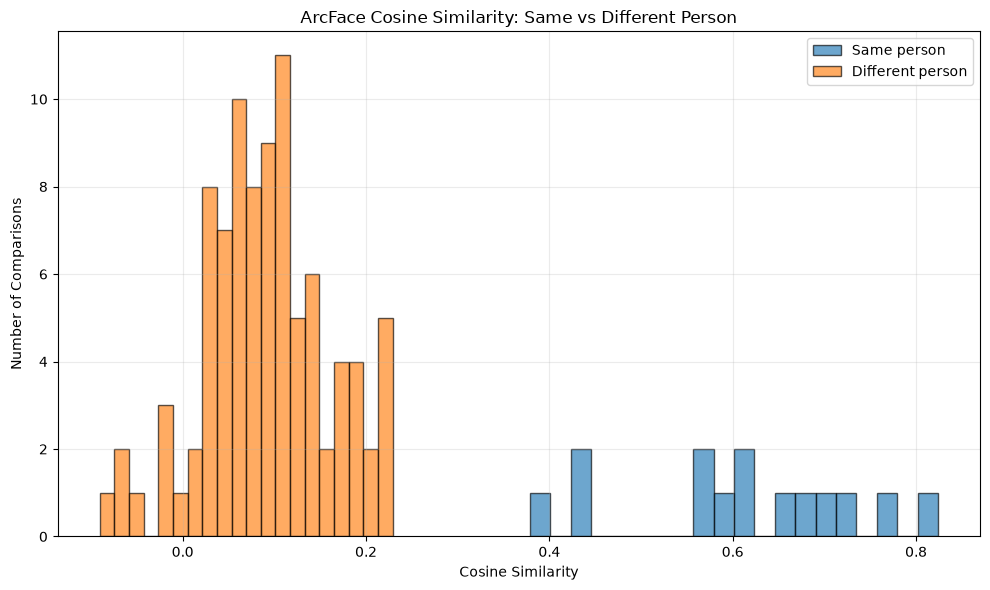

In [38]:
import matplotlib.pyplot as plt
import numpy as np

same_scores = same_df["similarity"].to_numpy()
different_scores = different_df["similarity"].to_numpy()

plt.figure(figsize=(10, 6))

plt.hist(
    same_scores,
    bins=20,
    alpha=0.65,
    label="Same person",
    edgecolor="black"
)

plt.hist(
    different_scores,
    bins=20,
    alpha=0.65,
    label="Different person",
    edgecolor="black"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Comparisons")
plt.title("ArcFace Cosine Similarity: Same vs Different Person")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

<b>2. Box plot — very good for comparison

This gives you median, spread and outliers.

This is particularly useful for understanding whether the distributions overlap.

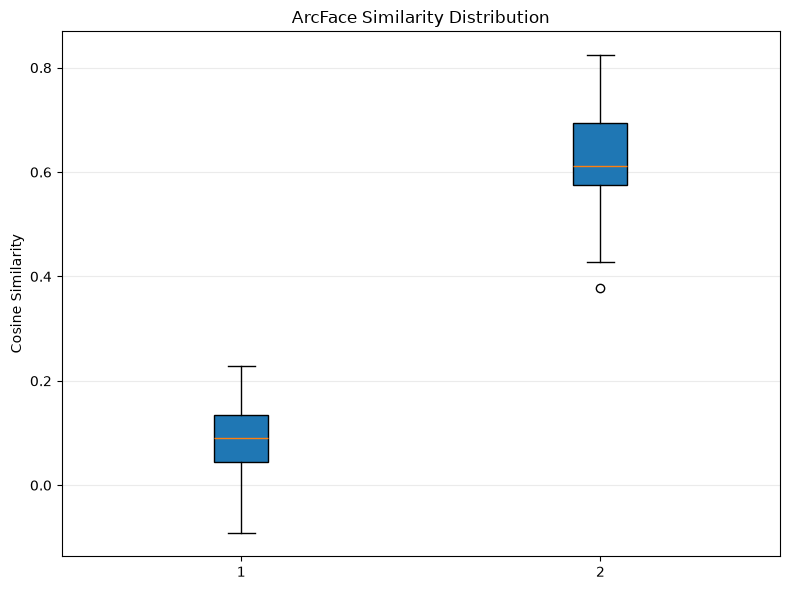

In [39]:
# 2. Box plot — very good for comparison
plt.figure(figsize=(8, 6))

plt.boxplot(
    [different_scores, same_scores],
    label=[
        "Different person",
        "Same person"
    ],
    patch_artist=True
)

plt.ylabel("Cosine Similarity")
plt.title("ArcFace Similarity Distribution")
plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

<b>3. Individual comparison scores

This let`s you see how much the similarity changes from person to person.

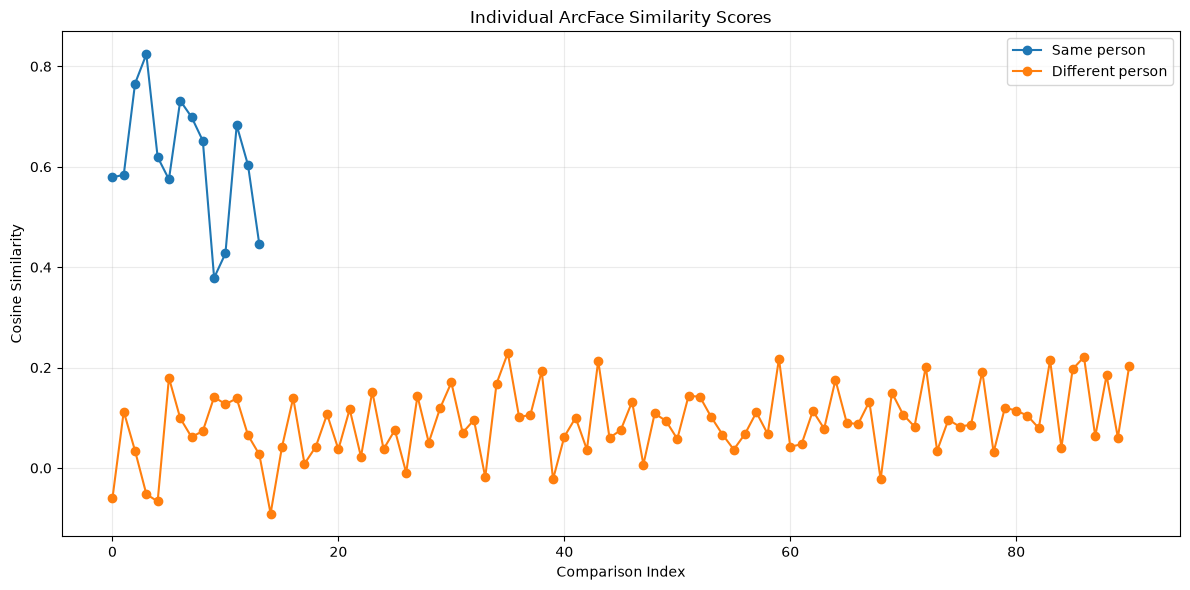

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(
    range(len(same_scores)),
    same_scores,
    marker="o",
    linestyle="-",
    label="Same person"
)

plt.plot(
    range(len(different_scores)),
    different_scores,
    marker="o",
    linestyle="-",
    label="Different person"
)

plt.xlabel("Comparison Index")
plt.ylabel("Cosine Similarity")
plt.title("Individual ArcFace Similarity Scores")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

<b>4. Print useful statistics

In [41]:
print("===== SAME PERSON =====")

print(f"Count  : {len(same_scores)}")
print(f"Mean   : {np.mean(same_scores):.4f}")
print(f"Median : {np.median(same_scores):.4f}")
print(f"Min    : {np.min(same_scores):.4f}")
print(f"Max    : {np.max(same_scores):.4f}")

print("\n===== DIFFERENT PERSON =====")

print(f"Count  : {len(different_scores)}")
print(f"Mean   : {np.mean(different_scores):.4f}")
print(f"Median : {np.median(different_scores):.4f}")
print(f"Min    : {np.min(different_scores):.4f}")
print(f"Max    : {np.max(different_scores):.4f}")

===== SAME PERSON =====
Count  : 14
Mean   : 0.6119
Median : 0.6113
Min    : 0.3788
Max    : 0.8240

===== DIFFERENT PERSON =====
Count  : 91
Mean   : 0.0910
Median : 0.0903
Min    : -0.0907
Max    : 0.2292


there is significant overlap, meaning the recognition threshold will be harder to choose.

Do not choose a threshold just from the mean. We should use the actual score distributions and calculate FAR/FRR.

### generate embeddings for all images

    Data/
    └── Embeddings/
        ├── embeddings.npy
        ├── metadata.csv
        └── ...

In [42]:
# First create the records
embedding_records = []

for i, image_path in enumerate(aligned_paths, start=1):

    try:

        embedding = generate_embedding(
            image_path
        )

        embedding_records.append({
            "person": image_path.parent.name,
            "filename": image_path.name,
            "path": str(image_path),
            "embedding": embedding
        })

        print(
            f"[{i}/{len(aligned_paths)}] "
            f"{image_path.parent.name}/{image_path.name}"
        )

    except Exception as e:

        print(
            f"FAILED: {image_path} → {e}"
        )

[1/213] Abhishek_Halagi/AH1.jpeg
[2/213] Abhishek_Halagi/AH10.jpeg
[3/213] Abhishek_Halagi/AH11.jpeg
[4/213] Abhishek_Halagi/AH13.jpeg
[5/213] Abhishek_Halagi/AH14.jpeg
[6/213] Abhishek_Halagi/AH15.jpeg
[7/213] Abhishek_Halagi/AH16.jpeg
[8/213] Abhishek_Halagi/AH17.jpeg
[9/213] Abhishek_Halagi/AH18.jpeg
[10/213] Abhishek_Halagi/AH19.jpeg
[11/213] Abhishek_Halagi/AH2.jpeg
[12/213] Abhishek_Halagi/AH3.jpeg
[13/213] Abhishek_Halagi/AH4.jpeg
[14/213] Abhishek_Halagi/AH5.jpeg
[15/213] Abhishek_Halagi/AH6.jpeg
[16/213] Abhishek_Halagi/AH7.jpeg
[17/213] Abhishek_Halagi/AH9.jpeg
[18/213] Darshan_Khadakhadi/DK1.jpeg
[19/213] Darshan_Khadakhadi/DK10.jpeg
[20/213] Darshan_Khadakhadi/DK11.jpeg
[21/213] Darshan_Khadakhadi/DK12.jpeg
[22/213] Darshan_Khadakhadi/DK13.jpeg
[23/213] Darshan_Khadakhadi/DK14.jpeg
[24/213] Darshan_Khadakhadi/DK15.jpeg
[25/213] Darshan_Khadakhadi/DK2.jpeg
[26/213] Darshan_Khadakhadi/DK3.jpeg
[27/213] Darshan_Khadakhadi/DK4.jpeg
[28/213] Darshan_Khadakhadi/DK5.jpeg
[29/213] 

In [43]:
# Separate embeddings and metadata
embeddings = np.vstack([
    record["embedding"]
    for record in embedding_records
])

metadata = pd.DataFrame([
    {
        "person": record["person"],
        "filename": record["filename"],
        "path": record["path"]
    }
    for record in embedding_records
])

In [44]:
print("Embeddings shape:", embeddings.shape)
print("Metadata shape:", metadata.shape)

Embeddings shape: (213, 512)
Metadata shape: (213, 3)


In [45]:
# Save the embedding database
embedding_file = EMBEDDINGS_DIR / "embeddings.npy"
metadata_file = EMBEDDINGS_DIR / "metadata.csv"

np.save(
    embedding_file,
    embeddings
)

metadata.to_csv(
    metadata_file,
    index=False
)

print("Embeddings saved to:", embedding_file)
print("Metadata saved to:", metadata_file)

Embeddings saved to: Data\Embeddings\embeddings.npy
Metadata saved to: Data\Embeddings\metadata.csv


<b>Very important

Don't treat embeddings.npy + metadata.csv as the final recognition system yet.

We still need to validate:

    213 embeddings
          ↓
    same-person comparisons
          ↓
    different-person comparisons
          ↓
    threshold selection
          ↓
    recognition accuracy

In [46]:
# Verify embedding normalization
embedding_norms = np.linalg.norm(
    embeddings,
    axis=1
)

print("Minimum norm:", embedding_norms.min())
print("Maximum norm:", embedding_norms.max())
print("Mean norm:", embedding_norms.mean())

Minimum norm: 0.9999999
Maximum norm: 1.0000001
Mean norm: 1.0


In [47]:
print(
    "All normalized:",
    np.allclose(embedding_norms, 1.0, atol=1e-5)
)

All normalized: True


In [48]:
# Save the database
embedding_file = EMBEDDINGS_DIR / "embeddings.npy"
metadata_file = EMBEDDINGS_DIR / "metadata.csv"

np.save(
    embedding_file,
    embeddings
)

metadata.to_csv(
    metadata_file,
    index=False
)

print("Saved embeddings:")
print(embedding_file.resolve())

print("\nSaved metadata:")
print(metadata_file.resolve())

Saved embeddings:
D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\Data\Embeddings\embeddings.npy

Saved metadata:
D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\Data\Embeddings\metadata.csv


In [49]:
# Verify that the database can be loaded
loaded_embeddings = np.load(
    embedding_file
)

loaded_metadata = pd.read_csv(
    metadata_file
)

print("Loaded embeddings:", loaded_embeddings.shape)
print("Loaded metadata:", loaded_metadata.shape)

Loaded embeddings: (213, 512)
Loaded metadata: (213, 3)


In [50]:
# Verify the rows correspon
assert len(loaded_embeddings) == len(loaded_metadata)

print("Database integrity check: PASSED")

Database integrity check: PASSED


<b>Now do the proper similarity analysis

This is where we improve upon the preliminary graphs you just made.

Previously you compared only a limited number of pairs.

Now we have all 213 embeddings.

We can calculate:

Genuine pairs

Two images belonging to the same person.

Impostor pairs

Two images belonging to different people.

For 213 images, this gives us a much stronger statistical basis for threshold selection.

In [51]:
from itertools import combinations

genuine_scores = []
impostor_scores = []

for i, j in combinations(range(len(embeddings)), 2):

    similarity = float(
        np.dot(
            embeddings[i],
            embeddings[j]
        )
    )

    person_i = metadata.iloc[i]["person"]
    person_j = metadata.iloc[j]["person"]

    if person_i == person_j:
        genuine_scores.append(similarity)
    else:
        impostor_scores.append(similarity)

print("Genuine comparisons:", len(genuine_scores))
print("Impostor comparisons:", len(impostor_scores))

Genuine comparisons: 1900
Impostor comparisons: 20678


<B>Generate the proper distribution plot

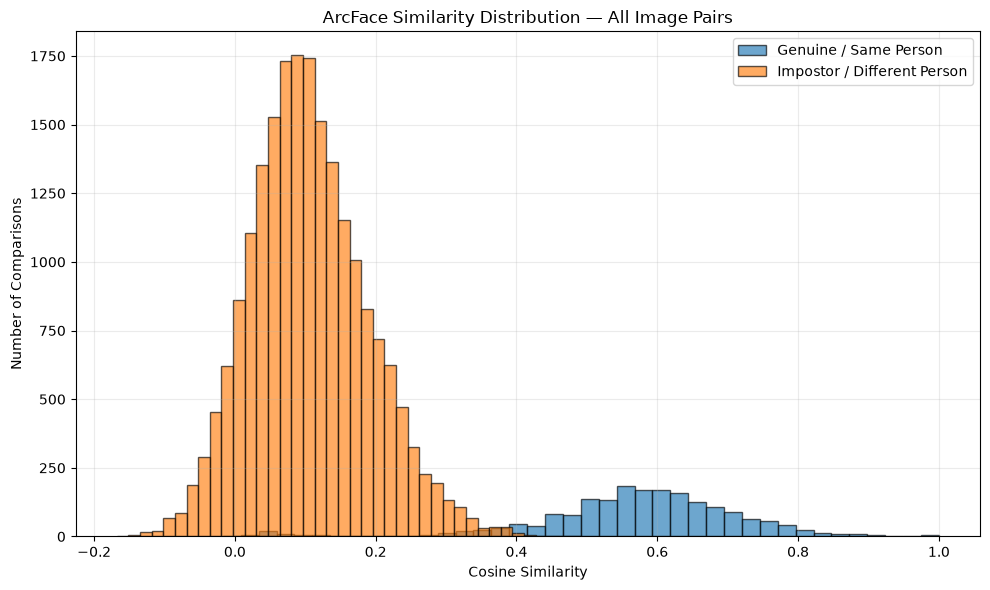

In [52]:
plt.figure(figsize=(10, 6))

plt.hist(
    genuine_scores,
    bins=40,
    alpha=0.65,
    label="Genuine / Same Person",
    edgecolor="black"
)

plt.hist(
    impostor_scores,
    bins=40,
    alpha=0.65,
    label="Impostor / Different Person",
    edgecolor="black"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Comparisons")

plt.title(
    "ArcFace Similarity Distribution — All Image Pairs"
)

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [53]:
print("===== GENUINE / SAME PERSON =====")

print(f"Count : {len(genuine_scores)}")
print(f"Min   : {np.min(genuine_scores):.4f}")
print(f"Mean  : {np.mean(genuine_scores):.4f}")
print(f"Median: {np.median(genuine_scores):.4f}")
print(f"Max   : {np.max(genuine_scores):.4f}")


print("\n===== IMPOSTOR / DIFFERENT PERSON =====")

print(f"Count : {len(impostor_scores)}")
print(f"Min   : {np.min(impostor_scores):.4f}")
print(f"Mean  : {np.mean(impostor_scores):.4f}")
print(f"Median: {np.median(impostor_scores):.4f}")
print(f"Max   : {np.max(impostor_scores):.4f}")

===== GENUINE / SAME PERSON =====
Count : 1900
Min   : -0.0171
Mean  : 0.5746
Median: 0.5829
Max   : 1.0000

===== IMPOSTOR / DIFFERENT PERSON =====
Count : 20678
Min   : -0.1678
Mean  : 0.1057
Median: 0.0990
Max   : 0.4935


#### threshold evaluation using FAR and FRR.

<b>Calculate FAR and FRR<\b><br>
For a threshold T:

    Similarity >= T
           ↓
         MATCH

    Similarity < T
           ↓
       NON-MATCH

1.  False Accept Rate — FAR <br>
Different people incorrectly accepted as the same person.<br>

*     FAR     = impostor scores >= threshold 
              -------------------------------- 
              total impostor scores<br>

2.  False Reject Rate — FRR<br>
Same person incorrectly rejected.

*     FRR    = genuine scores < threshold 
             ---------------------------- 
              total genuine scores

In [54]:
def calculate_far_frr(threshold, genuine_scores, impostor_scores):
    
    genuine_scores = np.asarray(genuine_scores)
    impostor_scores = np.asarray(impostor_scores)

    false_rejects = np.sum(genuine_scores < threshold)
    false_accepts = np.sum(impostor_scores >= threshold)

    frr = false_rejects / len(genuine_scores)
    far = false_accepts / len(impostor_scores)

    return far, frr

In [55]:
# Test different thresholds
thresholds = np.arange(0.0, 1.001, 0.01)

results = []

for threshold in thresholds:

    far, frr = calculate_far_frr(
        threshold,
        genuine_scores,
        impostor_scores
    )

    results.append({
        "threshold": threshold,
        "FAR": far,
        "FRR": frr
    })

threshold_df = pd.DataFrame(results)

threshold_df.head()

,threshold,FAR,FRR
0,0.00,0.910726,0.001579
1,0.01,0.884999,0.001579
2,0.02,0.855837,0.002105
3,0.03,0.822130,0.003684
4,0.04,0.785231,0.006842


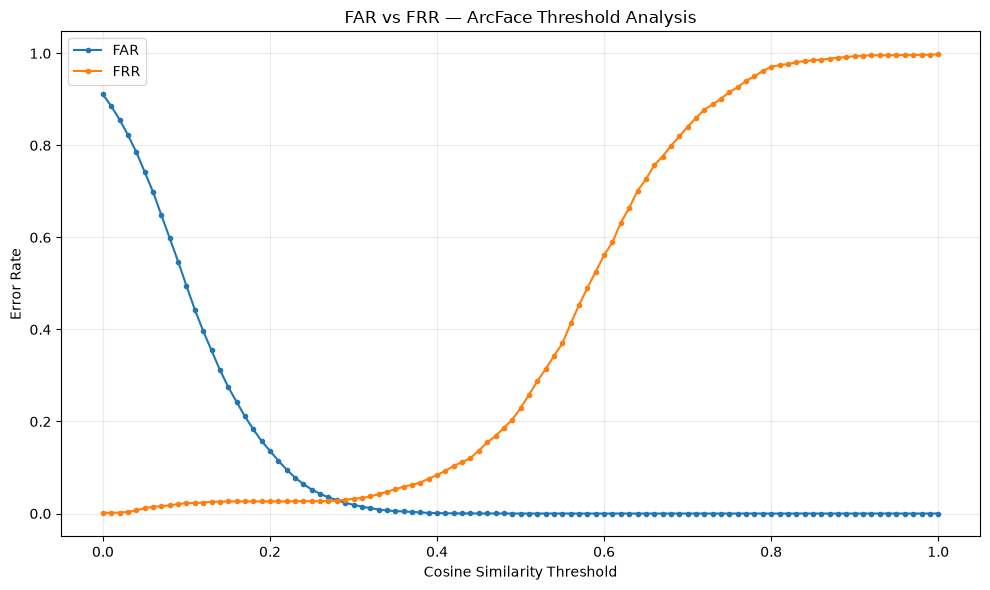

In [56]:
#Plot FAR vs FRR

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["FAR"],
    marker="o",
    markersize=3,
    label="FAR"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["FRR"],
    marker="o",
    markersize=3,
    label="FRR"
)

plt.xlabel("Cosine Similarity Threshold")
plt.ylabel("Error Rate")
plt.title("FAR vs FRR — ArcFace Threshold Analysis")

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

In [57]:
# Find the Equal Error Rate threshold 
# we can find the thrishold where FAR ~ FRR

threshold_df["difference"] = abs(
    threshold_df["FAR"] -
    threshold_df["FRR"]
)

eer_row = threshold_df.loc[
    threshold_df["difference"].idxmin()
]

print("EER operating threshold:")
print(eer_row)

EER operating threshold:
threshold     0.280000
FAR           0.029307
FRR           0.027895
difference    0.001412
Name: 28, dtype: float64


<b>Find a threshold prioritizing security

For this face-recognition system, I would not automatically use EER.

my system is intended to recognize family/classmate identities, so an incorrect identity can be more problematic than saying:

Unknown

Therefore, we may want to prioritize low FAR.

For example, find the lowest threshold where FAR ≤ 1%:

In [58]:
low_far = threshold_df[
    threshold_df["FAR"] <= 0.01
]

if len(low_far) > 0:
    best_low_far = low_far.iloc[0]

    print("Threshold with FAR <= 1%:")
    print(best_low_far)
else:
    print("No threshold achieves FAR <= 1%.")

Threshold with FAR <= 1%:
threshold     0.330000
FAR           0.008753
FRR           0.042105
difference    0.033352
Name: 33, dtype: float64


In [59]:
# u cann similarly ttest 0.5%

low_far = threshold_df[
    threshold_df["FAR"] <= 0.005
]

if len(low_far) > 0:
    print(
        low_far.iloc[0]
    )

threshold     0.360000
FAR           0.004498
FRR           0.058421
difference    0.053924
Name: 36, dtype: float64


**Find the worst genuine matches**

This is very important for your dataset because your minimum genuine similarity is only:

-0.0171

We need to find out which images are causing this.

Don't ignore this result.

In [60]:
# Recalculate genuine pair information
genuine_pairs = []

for i, j in combinations(range(len(embeddings)), 2):

    person_i = metadata.iloc[i]["person"]
    person_j = metadata.iloc[j]["person"]

    if person_i == person_j:

        similarity = float(
            np.dot(
                embeddings[i],
                embeddings[j]
            )
        )

        genuine_pairs.append({
            "person": person_i,
            "image_1": metadata.iloc[i]["filename"],
            "image_2": metadata.iloc[j]["filename"],
            "similarity": similarity
        })

genuine_pairs_df = pd.DataFrame(genuine_pairs)

In [61]:
# sort the pairs
worst_genuine = genuine_pairs_df.sort_values(
    "similarity",
    ascending=True
)

worst_genuine.head(20)

,person,image_1,image_2,similarity
323,Dhurvankur_,D1.jpeg,D3.jpeg,-0.017088
505,Dhurvankur_,D23.jpeg,D3.jpeg,-0.011498
413,Dhurvankur_,D14.jpeg,D3.jpeg,-0.004511
1370,Sahil_Patil,SP11.jpeg,SP37.jpeg,0.014270
523,Dhurvankur_,D26.jpeg,D3.jpeg,0.022874
1423,Sahil_Patil,SP13.jpeg,SP37.jpeg,0.026391
455,Dhurvankur_,D18.jpeg,D3.jpeg,0.026679
1448,Sahil_Patil,SP14.jpeg,SP37.jpeg,0.030360
343,Dhurvankur_,D10.jpeg,D3.jpeg,0.036581
1742,Sahil_Patil,SP37.jpeg,SP7.jpeg,0.037319


**Find the most dangerous impostor pairs**

Your highest impostor similarity is:

0.4935

We should find exactly which people/images produced it.

This is extremely useful. 
We want to inspect the highest-scoring different-person pairs.

In [62]:
impostor_pairs = []

for i, j in combinations(range(len(embeddings)), 2):

    person_i = metadata.iloc[i]["person"]
    person_j = metadata.iloc[j]["person"]

    if person_i != person_j:

        similarity = float(
            np.dot(
                embeddings[i],
                embeddings[j]
            )
        )

        impostor_pairs.append({
            "person_1": person_i,
            "person_2": person_j,
            "image_1": metadata.iloc[i]["filename"],
            "image_2": metadata.iloc[j]["filename"],
            "similarity": similarity
        })

impostor_pairs_df = pd.DataFrame(impostor_pairs)

In [63]:
worst_impostors = impostor_pairs_df.sort_values(
    "similarity",
    ascending=False
)

worst_impostors.head(20)

,person_1,person_2,image_1,image_2,similarity
15326,Nikhil_Kanbarkar,Sahil_Kurbet,NK18.jpeg,SK4.jpeg,0.493528
15325,Nikhil_Kanbarkar,Sahil_Kurbet,NK18.jpeg,SK3.jpeg,0.487052
9350,Dhurvankur_,Sahil_Patil,D18.jpeg,SP18.jpeg,0.478914
14845,Nikhil_Kanbarkar,Sahil_Kurbet,NK13.jpeg,SK3.jpeg,0.449760
6209,Darshan_Netegal,Vishwanath_Muchandi,DN.jpeg,VM16.jpeg,0.443462
15324,Nikhil_Kanbarkar,Sahil_Kurbet,NK18.jpeg,SK2.jpeg,0.443266
16871,Nikhil_Kanbarkar,Sahil_Patil,NK7.jpeg,SP18.jpeg,0.433539
16861,Nikhil_Kanbarkar,Sahil_Kurbet,NK7.jpeg,SK3.jpeg,0.422940
10535,Dhurvankur_,Sahil_Patil,D26.jpeg,SP27.jpeg,0.418116
10379,Dhurvankur_,Sahil_Patil,D25.jpeg,SP18.jpeg,0.415214


One important conclusion already

Your earlier visualizations showed a very clean separation because they used a smaller subset of comparisons. The full 22,578-pair analysis is the one we should trust for threshold selection.

Also, the -0.0171 genuine score deserves investigation. It could indicate a difficult pose/lighting/expression/image-quality case, an alignment issue, or even a dataset/person-label problem. We should identify those images before deciding that the model itself is performing poorly.

**Problem 1 — Very low genuine similarities**
Your worst genuine pairs are dominated by:
    Dhurvankur_ → D3.jpeg
    Sahil_Patil  → SP37.jpeg

    for example:
    D1  ↔ D3    = -0.017
    D23 ↔ D3    = -0.011
    D14 ↔ D3    = -0.004
    
    SP11 ↔ SP37 = 0.014
    SP13 ↔ SP37 = 0.026
    SP14 ↔ SP37 = 0.030

This is suspicious.

It suggests that D3 and SP37 may be problematic/outlier images, rather than immediately concluding that ArcFace is bad.

We need to visually inspect them.

**Problem 2 — Some different people have relatively high similarity**
Your worst impostor pair:

Nikhil_Kanbarkar / NK18.jpeg <br>
Sahil_Kurbet    / SK4.jpeg

Similarity = 0.4935

This is the most important impostor pair.

At a threshold of 0.36, this pair would be incorrectly accepted.

So we need to inspect these images too.

**First inspect the worst genuine pairs**

In [64]:
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

In [65]:
def show_image_pair(path1, path2, title):
    
    img1 = cv2.imread(str(path1))
    img2 = cv2.imread(str(path2))
    
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img1)
    plt.axis("off")
    plt.title(path1.name)

    plt.subplot(1, 2, 2)
    plt.imshow(img2)
    plt.axis("off")
    plt.title(path2.name)

    plt.suptitle(title)

    plt.tight_layout()
    plt.show()

In [66]:
# Display D3 against several of its genuine pairs
d3_pairs = genuine_pairs_df[
    (genuine_pairs_df["image_1"] == "D3.jpeg") |
    (genuine_pairs_df["image_2"] == "D3.jpeg")
].sort_values(
    "similarity"
)

d3_pairs.head(10)

,person,image_1,image_2,similarity
323,Dhurvankur_,D1.jpeg,D3.jpeg,-0.017088
505,Dhurvankur_,D23.jpeg,D3.jpeg,-0.011498
413,Dhurvankur_,D14.jpeg,D3.jpeg,-0.004511
523,Dhurvankur_,D26.jpeg,D3.jpeg,0.022874
455,Dhurvankur_,D18.jpeg,D3.jpeg,0.026679
343,Dhurvankur_,D10.jpeg,D3.jpeg,0.036581
442,Dhurvankur_,D16.jpeg,D3.jpeg,0.037387
362,Dhurvankur_,D11.jpeg,D3.jpeg,0.038900
530,Dhurvankur_,D3.jpeg,D8.jpeg,0.040192
478,Dhurvankur_,D2.jpeg,D3.jpeg,0.040960


In [67]:
def find_aligned_image(person, filename):
    
    path = ALIGNED_DIR / person / filename
    
    if path.exists():
        return path
    
    raise FileNotFoundError(path)

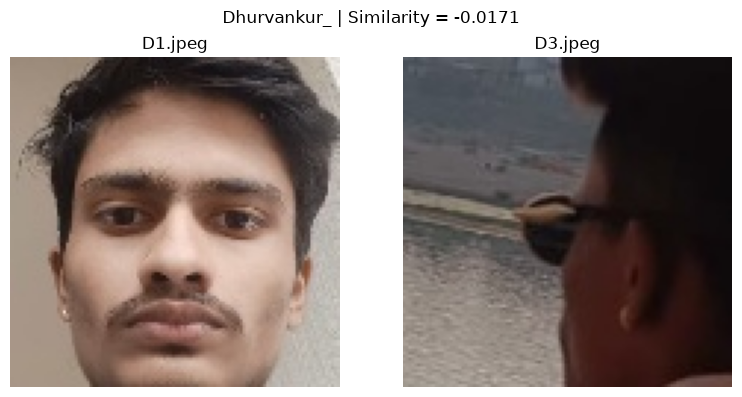

In [68]:
row = d3_pairs.iloc[0]

path1 = find_aligned_image(
    row["person"],
    row["image_1"]
)

path2 = find_aligned_image(
    row["person"],
    row["image_2"]
)

show_image_pair(
    path1,
    path2,
    f'{row["person"]} | Similarity = {row["similarity"]:.4f}'
)

Look specifically for:
*  extreme pose
* eyes partially closed
* face too small before alignment
* heavy blur
* unusual illumination
* incorrect landmark alignment
* occlusion
* facial crop cutting important regions
* image that visually doesn't look like the same person

In [69]:
# Inspect SP37 in the same way

In [70]:
sp37_pairs = genuine_pairs_df[
    (genuine_pairs_df["image_1"] == "SP37.jpeg") |
    (genuine_pairs_df["image_2"] == "SP37.jpeg")
].sort_values(
    "similarity"
)

sp37_pairs.head(10)

,person,image_1,image_2,similarity
1370,Sahil_Patil,SP11.jpeg,SP37.jpeg,0.014270
1423,Sahil_Patil,SP13.jpeg,SP37.jpeg,0.026391
1448,Sahil_Patil,SP14.jpeg,SP37.jpeg,0.030360
1742,Sahil_Patil,SP37.jpeg,SP7.jpeg,0.037319
1643,Sahil_Patil,SP25.jpeg,SP37.jpeg,0.039807
1733,Sahil_Patil,SP36.jpeg,SP37.jpeg,0.044227
1720,Sahil_Patil,SP32.jpeg,SP37.jpeg,0.047532
1743,Sahil_Patil,SP37.jpeg,SP9.jpeg,0.053851
1712,Sahil_Patil,SP31.jpeg,SP37.jpeg,0.054457
1397,Sahil_Patil,SP12.jpeg,SP37.jpeg,0.054720


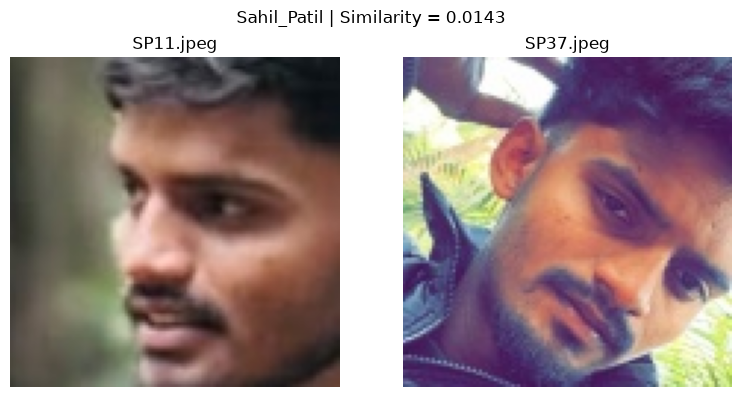

In [71]:
row = sp37_pairs.iloc[0]

path1 = find_aligned_image(
    row["person"],
    row["image_1"]
)

path2 = find_aligned_image(
    row["person"],
    row["image_2"]
)

show_image_pair(
    path1,
    path2,
    f'{row["person"]} | Similarity = {row["similarity"]:.4f}'
)

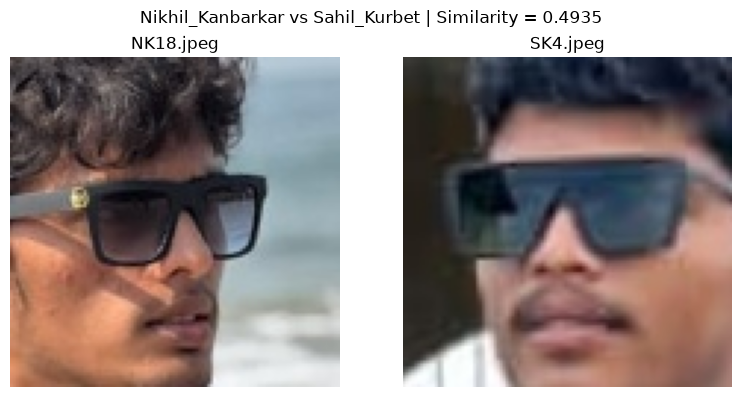

In [72]:
#inspect the worst impostor pair
row = worst_impostors.iloc[0]

path1 = find_aligned_image(
    row["person_1"],
    row["image_1"]
)

path2 = find_aligned_image(
    row["person_2"],
    row["image_2"]
)

show_image_pair(
    path1,
    path2,
    (
        f'{row["person_1"]} vs {row["person_2"]} | '
        f'Similarity = {row["similarity"]:.4f}'
    )
)

In [73]:
worst_impostors.head(5)

,person_1,person_2,image_1,image_2,similarity
15326,Nikhil_Kanbarkar,Sahil_Kurbet,NK18.jpeg,SK4.jpeg,0.493528
15325,Nikhil_Kanbarkar,Sahil_Kurbet,NK18.jpeg,SK3.jpeg,0.487052
9350,Dhurvankur_,Sahil_Patil,D18.jpeg,SP18.jpeg,0.478914
14845,Nikhil_Kanbarkar,Sahil_Kurbet,NK13.jpeg,SK3.jpeg,0.449760
6209,Darshan_Netegal,Vishwanath_Muchandi,DN.jpeg,VM16.jpeg,0.443462


The goal is to determine whether these high similarities are caused by:

    genuinely similar-looking people,
    similar pose/lighting,
    poor alignment,
    duplicate/incorrectly labeled images,
    or something else.

Delete/quarantine an image if it is both a statistical outlier AND visually/technically problematic.

Clearly bad image
    ↓
REMOVE from recognition database

Good but difficult image
    ↓
KEEP

Statistical outlier + visibly questionable
    ↓
REMOVE

**Find which individual images are causing problems**

In [74]:
from itertools import combinations
from collections import defaultdict
import numpy as np
import pandas as pd

In [75]:
image_stats = []

for i in range(len(embeddings)):

    person_i = metadata.iloc[i]["person"]

    genuine_scores_i = []
    impostor_scores_i = []

    for j in range(len(embeddings)):

        if i == j:
            continue

        similarity = float(
            np.dot(
                embeddings[i],
                embeddings[j]
            )
        )

        person_j = metadata.iloc[j]["person"]

        if person_i == person_j:
            genuine_scores_i.append(similarity)
        else:
            impostor_scores_i.append(similarity)

    image_stats.append({
        "index": i,
        "person": person_i,
        "filename": metadata.iloc[i]["filename"],

        # How well this image matches its own person
        "genuine_mean": np.mean(genuine_scores_i),
        "genuine_median": np.median(genuine_scores_i),
        "genuine_min": np.min(genuine_scores_i),

        # How similar it is to other people
        "impostor_max": np.max(impostor_scores_i),
        "impostor_mean": np.mean(impostor_scores_i)
    })

image_stats_df = pd.DataFrame(image_stats)

image_stats_df.head()

,index,person,filename,genuine_mean,genuine_median,genuine_min,impostor_max,impostor_mean
0,0,Abhishek_Halagi,AH1.jpeg,0.666985,0.694776,0.458473,0.319149,0.068739
1,1,Abhishek_Halagi,AH10.jpeg,0.566152,0.565683,0.515858,0.387227,0.089755
2,2,Abhishek_Halagi,AH11.jpeg,0.609625,0.622646,0.507815,0.397325,0.100222
3,3,Abhishek_Halagi,AH13.jpeg,0.550582,0.544693,0.486999,0.378465,0.106576
4,4,Abhishek_Halagi,AH14.jpeg,0.697737,0.721490,0.452787,0.264997,0.061581


In [76]:
# find the worst genuine images
worst_genuine_images = image_stats_df.sort_values(
    "genuine_median",
    ascending=True
)

worst_genuine_images[
    [
        "person",
        "filename",
        "genuine_mean",
        "genuine_median",
        "genuine_min",
        "impostor_max"
    ]
].head(20)

,person,filename,genuine_mean,genuine_median,genuine_min,impostor_max
61,Dhurvankur_,D3.jpeg,0.040670,0.042043,-0.017088,0.163206
182,Sahil_Patil,SP37.jpeg,0.077141,0.078154,0.014270,0.153873
89,Mahesh_Oulkar,MO7.jpeg,0.336629,0.342619,0.295766,0.246571
152,Rohit_Patil,RP9.jpeg,0.368417,0.354597,0.227323,0.268527
183,Sahil_Patil,SP4.jpeg,0.362073,0.365014,0.146844,0.328343
129,Rohit_Patil,RP1.jpeg,0.383500,0.378821,0.299894,0.290385
146,Rohit_Patil,RP30.jpeg,0.402118,0.391704,0.307134,0.202261
181,Sahil_Patil,SP36.jpeg,0.407580,0.407894,0.044227,0.378719
135,Rohit_Patil,RP17.jpeg,0.414468,0.411314,0.321070,0.254625
151,Rohit_Patil,RP8.jpeg,0.409733,0.412834,0.282465,0.159024


Note:If an image repeatedly performs badly against many images of its own person, it is a much stronger outlier candidate.

In [77]:
# finding the images causing dangerous impostor matches
worst_impostor_images = image_stats_df.sort_values(
    "impostor_max",
    ascending=False
)

worst_impostor_images[
    [
        "person",
        "filename",
        "genuine_mean",
        "genuine_median",
        "genuine_min",
        "impostor_max"
    ]
].head(20)

,person,filename,genuine_mean,genuine_median,genuine_min,impostor_max
99,Nikhil_Kanbarkar,NK18.jpeg,0.561765,0.572483,0.390071,0.493528
156,Sahil_Kurbet,SK4.jpeg,0.626951,0.568826,0.505518,0.493528
155,Sahil_Kurbet,SK3.jpeg,0.633842,0.578222,0.514288,0.487052
165,Sahil_Patil,SP18.jpeg,0.537657,0.550653,0.066692,0.478914
52,Dhurvankur_,D18.jpeg,0.592987,0.618887,0.026679,0.478914
94,Nikhil_Kanbarkar,NK13.jpeg,0.641434,0.610201,0.552914,0.449760
32,Darshan_Netegal,DN.jpeg,0.676151,0.743428,0.411196,0.443462
206,Vishwanath_Muchandi,VM16.jpeg,0.603893,0.602482,0.440728,0.443462
154,Sahil_Kurbet,SK2.jpeg,0.525236,0.518234,0.427284,0.443266
115,Nikhil_Kanbarkar,NK7.jpeg,0.608806,0.607612,0.497088,0.433539


Step 4 — Create an overall outlier ranking

For your dataset, I would use two signals:

Signal A — Low genuine similarity

The image doesn't resemble other images of its own person.

Signal B — High impostor similarity

The image resembles another person too strongly.

Create normalized rankings:

In [78]:
image_stats_df["genuine_rank"] = (
    image_stats_df["genuine_median"]
    .rank(ascending=True, pct=True)
)

image_stats_df["impostor_rank"] = (
    image_stats_df["impostor_max"]
    .rank(ascending=False, pct=True)
)

In [79]:
image_stats_df["outlier_score"] = (
    image_stats_df["genuine_rank"] +
    image_stats_df["impostor_rank"]
)

In [80]:
outlier_candidates = image_stats_df.sort_values(
    "outlier_score"
)

outlier_candidates[
    [
        "person",
        "filename",
        "genuine_median",
        "genuine_min",
        "impostor_max",
        "outlier_score"
    ]
].head(20)

,person,filename,genuine_median,genuine_min,impostor_max,outlier_score
174,Sahil_Patil,SP27.jpeg,0.468340,0.121508,0.418116,0.124413
173,Sahil_Patil,SP26.jpeg,0.464523,0.123325,0.389547,0.178404
154,Sahil_Kurbet,SK2.jpeg,0.518234,0.427284,0.443266,0.220657
166,Sahil_Patil,SP19.jpeg,0.478622,0.084606,0.386230,0.225352
165,Sahil_Patil,SP18.jpeg,0.550653,0.066692,0.478914,0.246479
181,Sahil_Patil,SP36.jpeg,0.407894,0.044227,0.378719,0.248826
170,Sahil_Patil,SP23.jpeg,0.461998,0.089872,0.377664,0.281690
209,Vishwanath_Muchandi,VM3.jpeg,0.485173,0.372490,0.378924,0.305164
81,Harshad_Bhairatkar,HB9.jpeg,0.534005,0.448231,0.387135,0.328638
91,Mahesh_Oulkar,MO9.jpeg,0.531808,0.298489,0.386107,0.330986


Seperate folder for outlierxs

In [81]:
from pathlib import Path

OUTLIER_DIR = Path("./Data/Classmates_Outliers")

OUTLIER_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [83]:
outliers_to_remove = {
    ("Dhurvankur_", "D3.jpeg"),
    ("Sahil_Patil", "SP37.jpeg"),
}

In [84]:
# move selected outliers safeely
import shutil

for person, filename in outliers_to_remove:

    source = ALIGNED_DIR / person / filename

    destination_dir = OUTLIER_DIR / person
    destination_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    destination = destination_dir / filename

    if source.exists():

        shutil.move(
            str(source),
            str(destination)
        )

        print(f"Moved: {source}")
        print(f"     → {destination}")

    else:
        print(f"NOT FOUND: {source}")

Moved: Data\Classmates_Aligned\Dhurvankur_\D3.jpeg
     → Data\Classmates_Outliers\Dhurvankur_\D3.jpeg
Moved: Data\Classmates_Aligned\Sahil_Patil\SP37.jpeg
     → Data\Classmates_Outliers\Sahil_Patil\SP37.jpeg


In [85]:
# verify
remaining_images = [
    p
    for p in ALIGNED_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    }
]

outlier_images = [
    p
    for p in OUTLIER_DIR.rglob("*")
    if p.is_file()
]

print("Remaining aligned images:", len(remaining_images))
print("Moved to outliers:", len(outlier_images))

Remaining aligned images: 211
Moved to outliers: 2


This matters because face-recognition datasets should contain realistic intra-person variation. If we remove every difficult image, your system may perform well on your clean dataset but fail on real camera images.

For your current dataset, I would probably aim to remove only a small number of clearly problematic images, then rerun the complete evaluation.

After you move the confirmed outliers, we should regenerate the embeddings and rerun the 22,578-pair analysis. Then we'll see whether the genuine distribution improves and whether the impostor maximum decreases. That will give us a much stronger basis for selecting the final recognition threshold.

### Rebuilding embeddings from the remaining aligned images
In your new/current notebook, use your existing paths. Assuming your aligned directory is Classmates_Aligned and your embedding directory is Embeddings:

In [86]:
from pathlib import Path
import numpy as np
import pandas as pd

# Paths
ALIGNED_DIR = Path("./Data/Classmates_Aligned")
EMBEDDINGS_DIR = Path("./Data/Embeddings")

EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

print("Aligned directory:", ALIGNED_DIR.resolve())
print("Embeddings directory:", EMBEDDINGS_DIR.resolve())

Aligned directory: D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\Data\Classmates_Aligned
Embeddings directory: D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\Data\Embeddings


In [87]:
image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

aligned_paths = sorted([
    p
    for p in ALIGNED_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in image_extensions
])

print("Remaining aligned images:", len(aligned_paths))

Remaining aligned images: 211


In [88]:
remaining_metadata = pd.DataFrame({
    "person": [p.parent.name for p in aligned_paths],
    "filename": [p.name for p in aligned_paths],
    "path": [str(p) for p in aligned_paths]
})

print(
    remaining_metadata["person"]
    .value_counts()
    .sort_index()
)

person
Abhishek_Halagi        17
Darshan_Khadakhadi     15
Darshan_Netegal        12
Dhurvankur_            21
Harshad_Bhairatkar     16
Mahesh_Oulkar          10
Nikhil_Kanbarkar       25
Pranav_Kavale           6
Rohan_Kamble            6
Rohit_Patil            24
Sahil_Kurbet            5
Sahil_Patil            29
Suraj_Mallur           14
Vishwanath_Muchandi    11
Name: count, dtype: int64


In [89]:
print("\nTotal:", len(remaining_metadata))
print("Unique people:", remaining_metadata["person"].nunique())


Total: 211
Unique people: 14


**Generate new ArcFace embeddings**

In [90]:
recognition_model

In [91]:
embedding_records = []

total = len(aligned_paths)

for i, image_path in enumerate(aligned_paths, start=1):

    try:
        embedding = generate_embedding(image_path)

        embedding_records.append({
            "person": image_path.parent.name,
            "filename": image_path.name,
            "path": str(image_path),
            "embedding": embedding
        })

        print(
            f"[{i:3d}/{total}] "
            f"{image_path.parent.name}/{image_path.name}"
        )

    except Exception as e:
        print(
            f"[{i:3d}/{total}] FAILED "
            f"{image_path.name}: {e}"
        )

[  1/211] Abhishek_Halagi/AH1.jpeg
[  2/211] Abhishek_Halagi/AH10.jpeg
[  3/211] Abhishek_Halagi/AH11.jpeg
[  4/211] Abhishek_Halagi/AH13.jpeg
[  5/211] Abhishek_Halagi/AH14.jpeg
[  6/211] Abhishek_Halagi/AH15.jpeg
[  7/211] Abhishek_Halagi/AH16.jpeg
[  8/211] Abhishek_Halagi/AH17.jpeg
[  9/211] Abhishek_Halagi/AH18.jpeg
[ 10/211] Abhishek_Halagi/AH19.jpeg
[ 11/211] Abhishek_Halagi/AH2.jpeg
[ 12/211] Abhishek_Halagi/AH3.jpeg
[ 13/211] Abhishek_Halagi/AH4.jpeg
[ 14/211] Abhishek_Halagi/AH5.jpeg
[ 15/211] Abhishek_Halagi/AH6.jpeg
[ 16/211] Abhishek_Halagi/AH7.jpeg
[ 17/211] Abhishek_Halagi/AH9.jpeg
[ 18/211] Darshan_Khadakhadi/DK1.jpeg
[ 19/211] Darshan_Khadakhadi/DK10.jpeg
[ 20/211] Darshan_Khadakhadi/DK11.jpeg
[ 21/211] Darshan_Khadakhadi/DK12.jpeg
[ 22/211] Darshan_Khadakhadi/DK13.jpeg
[ 23/211] Darshan_Khadakhadi/DK14.jpeg
[ 24/211] Darshan_Khadakhadi/DK15.jpeg
[ 25/211] Darshan_Khadakhadi/DK2.jpeg
[ 26/211] Darshan_Khadakhadi/DK3.jpeg
[ 27/211] Darshan_Khadakhadi/DK4.jpeg
[ 28/211] 

In [92]:
#Create the new embedding matrix
embeddings = np.vstack([
    record["embedding"]
    for record in embedding_records
]).astype(np.float32)

print("Embedding matrix shape:", embeddings.shape)

Embedding matrix shape: (211, 512)


In [93]:
# Crete new metadata
metadata = pd.DataFrame([
    {
        "person": record["person"],
        "filename": record["filename"],
        "path": record["path"]
    }
    for record in embedding_records
])

print(metadata.head())
print("\nMetadata shape:", metadata.shape)

            person   filename  \
0  Abhishek_Halagi   AH1.jpeg   
1  Abhishek_Halagi  AH10.jpeg   
2  Abhishek_Halagi  AH11.jpeg   
3  Abhishek_Halagi  AH13.jpeg   
4  Abhishek_Halagi  AH14.jpeg   

                                                path  
0   Data\Classmates_Aligned\Abhishek_Halagi\AH1.jpeg  
1  Data\Classmates_Aligned\Abhishek_Halagi\AH10.jpeg  
2  Data\Classmates_Aligned\Abhishek_Halagi\AH11.jpeg  
3  Data\Classmates_Aligned\Abhishek_Halagi\AH13.jpeg  
4  Data\Classmates_Aligned\Abhishek_Halagi\AH14.jpeg  

Metadata shape: (211, 3)


In [94]:
# Verify embeddings
embedding_norms = np.linalg.norm(
    embeddings,
    axis=1
)

print("Minimum norm:", embedding_norms.min())
print("Maximum norm:", embedding_norms.max())
print("Mean norm:", embedding_norms.mean())

print(
    "All normalized:",
    np.allclose(
        embedding_norms,
        1.0,
        atol=1e-5
    )
)

Minimum norm: 0.9999999
Maximum norm: 1.0000001
Mean norm: 1.0
All normalized: True


In [95]:
# Save the NEW database
# Use different filenames so there is no confusion with the old database:
embedding_file = EMBEDDINGS_DIR / "embeddings_clean.npy"
metadata_file = EMBEDDINGS_DIR / "metadata_clean.csv"

np.save(
    embedding_file,
    embeddings
)

metadata.to_csv(
    metadata_file,
    index=False
)

print("Saved:")
print(embedding_file.resolve())
print(metadata_file.resolve())

Saved:
D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\Data\Embeddings\embeddings_clean.npy
D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\Data\Embeddings\metadata_clean.csv


In [96]:
# Verify the new database
loaded_embeddings = np.load(
    embedding_file
)

loaded_metadata = pd.read_csv(
    metadata_file
)

print("Embeddings:", loaded_embeddings.shape)
print("Metadata:", loaded_metadata.shape)

assert loaded_embeddings.shape[0] == len(loaded_metadata)

print("\nDatabase integrity: PASSED")

Embeddings: (211, 512)
Metadata: (211, 3)

Database integrity: PASSED


### FINAL THRESHOLD EVLUATION ON THE CLEAN DATASET

**Recalculate genuine / impostor similarities**

In [97]:
embeddings
metadata

,person,filename,path
0,Abhishek_Halagi,AH1.jpeg,Data\Classmates_Aligned\Abhishek_Halagi\AH1.jpeg
1,Abhishek_Halagi,AH10.jpeg,Data\Classmates_Aligned\Abhishek_Halagi\AH10.jpeg
2,Abhishek_Halagi,AH11.jpeg,Data\Classmates_Aligned\Abhishek_Halagi\AH11.jpeg
3,Abhishek_Halagi,AH13.jpeg,Data\Classmates_Aligned\Abhishek_Halagi\AH13.jpeg
4,Abhishek_Halagi,AH14.jpeg,Data\Classmates_Aligned\Abhishek_Halagi\AH14.jpeg
...,...,...,...
206,Vishwanath_Muchandi,VM2.jpeg,Data\Classmates_Aligned\Vishwanath_Muchandi\VM...
207,Vishwanath_Muchandi,VM3.jpeg,Data\Classmates_Aligned\Vishwanath_Muchandi\VM...
208,Vishwanath_Muchandi,VM4.jpeg,Data\Classmates_Aligned\Vishwanath_Muchandi\VM...
209,Vishwanath_Muchandi,VM5.jpeg,Data\Classmates_Aligned\Vishwanath_Muchandi\VM...


In [105]:
embeddings

array([[ 0.02516045,  0.00424061, -0.00056733, ...,  0.09027269,
         0.0456144 ,  0.01710433],
       [-0.00034435,  0.04899479, -0.04237343, ...,  0.04825452,
         0.03402082,  0.02276948],
       [ 0.02874286,  0.00077036, -0.04113059, ...,  0.05473372,
         0.04321623,  0.01247674],
       ...,
       [ 0.00082392, -0.06003612, -0.03159773, ...,  0.05807782,
        -0.05752189,  0.01924096],
       [ 0.04423537, -0.08003311, -0.01728713, ...,  0.02648609,
        -0.02467558,  0.01539954],
       [ 0.07660573, -0.06348895, -0.000927  , ...,  0.06913608,
        -0.03631259, -0.00812448]], shape=(211, 512), dtype=float32)

In [115]:
from itertools import combinations
import numpy as np

genuine_scores = []
impostor_scores = []

for i, j in combinations(range(len(embeddings)), 2):

    similarity = float(
        np.dot(
            embeddings[i],
            embeddings[j]
        )
    )

    person_i = metadata.iloc[i]["person"]
    person_j = metadata.iloc[j]["person"]

    if person_i == person_j:
        genuine_scores.append(similarity)
    else:
        impostor_scores.append(similarity)

print("Genuine comparisons :", len(genuine_scores))
print("Impostor comparisons:", len(impostor_scores))
print("Total comparisons   :", len(genuine_scores) + len(impostor_scores))

Genuine comparisons : 1850
Impostor comparisons: 20305
Total comparisons   : 22155


In [116]:
print("===== GENUINE / SAME PERSON =====")

print(f"Count : {len(genuine_scores)}")
print(f"Min   : {np.min(genuine_scores):.4f}")
print(f"Mean  : {np.mean(genuine_scores):.4f}")
print(f"Median: {np.median(genuine_scores):.4f}")
print(f"Max   : {np.max(genuine_scores):.4f}")


print("\n===== IMPOSTOR / DIFFERENT PERSON =====")

print(f"Count : {len(impostor_scores)}")
print(f"Min   : {np.min(impostor_scores):.4f}")
print(f"Mean  : {np.mean(impostor_scores):.4f}")
print(f"Median: {np.median(impostor_scores):.4f}")
print(f"Max   : {np.max(impostor_scores):.4f}")

===== GENUINE / SAME PERSON =====
Count : 1850
Min   : 0.2273
Mean  : 0.5885
Median: 0.5861
Max   : 1.0000

===== IMPOSTOR / DIFFERENT PERSON =====
Count : 20305
Min   : -0.1678
Mean  : 0.1070
Median: 0.1005
Max   : 0.4935


**Plot the clean distribution**

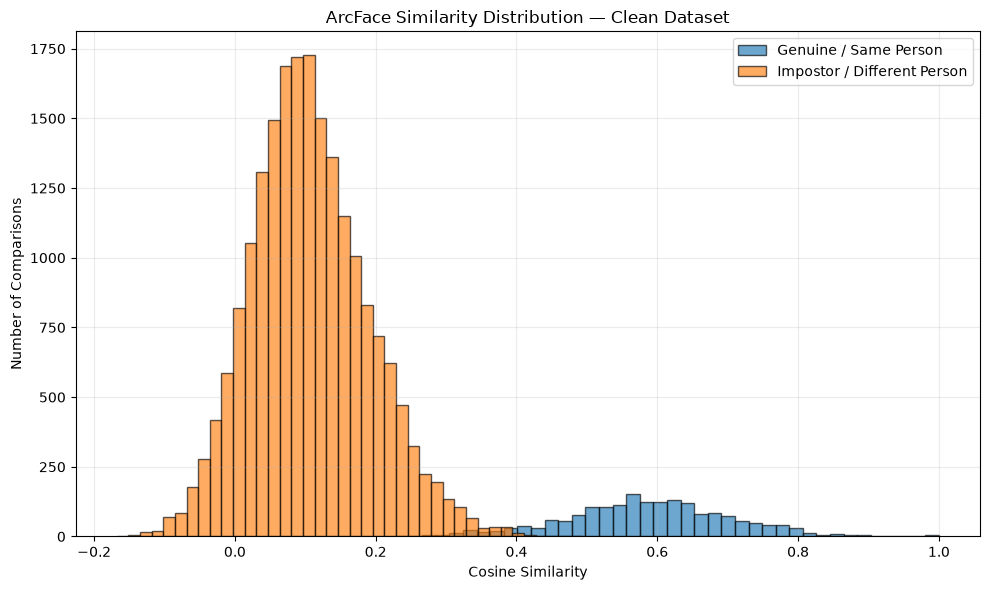

In [117]:
plt.figure(figsize=(10, 6))

plt.hist(
    genuine_scores,
    bins=40,
    alpha=0.65,
    label="Genuine / Same Person",
    edgecolor="black"
)

plt.hist(
    impostor_scores,
    bins=40,
    alpha=0.65,
    label="Impostor / Different Person",
    edgecolor="black"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Comparisons")
plt.title("ArcFace Similarity Distribution — Clean Dataset")

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

**recalculate FAR/FRR**

In [118]:
def calculate_far_frr(
    threshold,
    genuine_scores,
    impostor_scores
):
    
    genuine_scores = np.asarray(genuine_scores)
    impostor_scores = np.asarray(impostor_scores)

    false_rejects = np.sum(
        genuine_scores < threshold
    )

    false_accepts = np.sum(
        impostor_scores >= threshold
    )

    frr = false_rejects / len(genuine_scores)
    far = false_accepts / len(impostor_scores)

    return far, frr

In [121]:
#Return threshold evaluation
thresholds = np.arange(
    0.0,
    1.001,
    0.01
)

results = []

for threshold in thresholds:

    far, frr = calculate_far_frr(
        threshold,
        genuine_scores,
        impostor_scores
    )

    results.append({
        "threshold": threshold,
        "FAR": far,
        "FRR": frr
    })

threshold_df = pd.DataFrame(results)

threshold_df["difference"] = abs(
    threshold_df["FAR"] -
    threshold_df["FRR"]
)

In [122]:
# NEW EER threshold 
eer_row = threshold_df.loc[
    threshold_df["difference"].idxmin()
]

print("===== CLEAN DATASET EER =====")
print(eer_row)

===== CLEAN DATASET EER =====
threshold     0.320000
FAR           0.012017
FRR           0.011351
difference    0.000665
Name: 32, dtype: float64


In [123]:
# Find security-oriented thresholds
print("===== FAR <= 1% =====")

print(
    threshold_df[
        threshold_df["FAR"] <= 0.01
    ].head(10)
)

===== FAR <= 1% =====
    threshold       FAR       FRR  difference
33       0.33  0.008914  0.016216    0.007302
34       0.34  0.006895  0.021622    0.014727
35       0.35  0.005368  0.027027    0.021659
36       0.36  0.004580  0.032973    0.028393
37       0.37  0.003497  0.036757    0.033260
38       0.38  0.002462  0.042162    0.039700
39       0.39  0.001428  0.050811    0.049383
40       0.40  0.000985  0.058919    0.057934
41       0.41  0.000640  0.068108    0.067468
42       0.42  0.000394  0.079459    0.079065


In [124]:
print("===== FAR <= 0.5% =====")

print(
    threshold_df[
        threshold_df["FAR"] <= 0.005
    ]
)

===== FAR <= 0.5% =====
     threshold       FAR       FRR  difference
36        0.36  0.004580  0.032973    0.028393
37        0.37  0.003497  0.036757    0.033260
38        0.38  0.002462  0.042162    0.039700
39        0.39  0.001428  0.050811    0.049383
40        0.40  0.000985  0.058919    0.057934
..         ...       ...       ...         ...
96        0.96  0.000000  0.996216    0.996216
97        0.97  0.000000  0.996216    0.996216
98        0.98  0.000000  0.996757    0.996757
99        0.99  0.000000  0.996757    0.996757
100       1.00  0.000000  0.997838    0.997838

[65 rows x 4 columns]


This is more useful for our final system than simply taking EER.

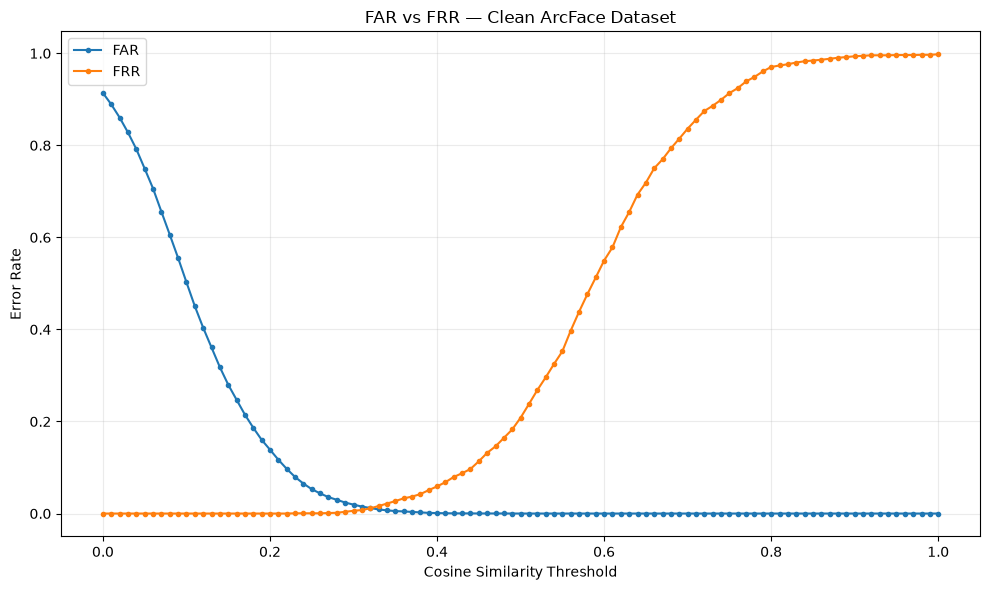

In [125]:
# plot FAR/FRR
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["FAR"],
    marker="o",
    markersize=3,
    label="FAR"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["FRR"],
    marker="o",
    markersize=3,
    label="FRR"
)

plt.xlabel("Cosine Similarity Threshold")
plt.ylabel("Error Rate")
plt.title("FAR vs FRR — Clean ArcFace Dataset")

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

In [126]:
# Save the threshold analysis 
threshold_results_file = (
    EMBEDDINGS_DIR / "threshold_analysis_clean.csv"
)

threshold_df.to_csv(
    threshold_results_file,
    index=False
)

print(
    "Saved:",
    threshold_results_file.resolve()
)

Saved: D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\Data\Embeddings\threshold_analysis_clean.csv


<h3>RESULT</h3>

Recommended final threshold

For your project, I recommend 0.36, not the EER threshold 0.32.

Why:

    0.32 → FAR ≈ 1.20%, FRR ≈ 1.14%
    0.36 → FAR ≈ 0.458%, FRR ≈ 3.30%

For a face-recognition system, reducing false accepts is generally more important than minimizing FRR, especially when deciding whether someone is a particular known person.

In [129]:
FINAL_THRESHOLD = 0.36

print(f"Final recognition threshold: {FINAL_THRESHOLD:.2f}")

Final recognition threshold: 0.36


<h3>final result</h3>

    Clean images       : 211
    Genuine pairs      : 1,850
    Impostor pairs     : 20,305
    Total comparisons  : 22,155
    
    EER threshold      : 0.32
    EER FAR            : 1.20%
    EER FRR            : 1.14%
    
    Selected threshold : 0.36
    FAR                : 0.458%
    FRR                : 3.297%

Important: 0.36 is our initial deployment threshold, not a universally optimal threshold. We'll validate it again with real camera/Raspberry Pi images later.

Now we can move to the actual face-recognition engine: input face → ArcFace embedding → compare against your 211-image database → best match → KNOWN/UNKNOWN.